# NB08 — Web of Microbes (WoM) Exometabolomic Prediction

**Project**: `genotype_to_phenotype_enigma`
**Depends on**: `NB02_wom_strain_crossmatch.ipynb` (strain matches), `NB05_feature_engineering.ipynb` (KO matrix), NB07 full-corpus predictions (only used for SHAP overlap scatter)

## Goal

Test **H5**: do growth-predictive KOs also predict metabolite production?

Two experiments:

1. **Multivariate GBDT** (leave-one-strain-out, 6 Pseudomonas WoM strains × 105 metabolites) — predict `produced` from KO presence. **Expected to fail** — n=6 strains with high Jaccard KO similarity (~0.81) give GBDT essentially no training signal for multivariate feature selection.
2. **Per-metabolite univariate correlation** using an **FB-cognate KO feature set** — KOs with significant fitness (|t|>4) in Fitness Browser rich-media (LB/R2A) experiments on Pseudomonas anchor strains. This yields a mechanistically focused feature space (~1,000 KOs) instead of the full 7,167. Per-metabolite point-biserial correlation against binary production recovers strong gene-metabolite associations.

## Key findings

- Multivariate GBDT: **AUC = 0.500** for all 6 strains — predictions are constant per strain (the model has no KO-level variation to learn from with n=6).
- Per-metabolite correlation: **~500+ strong associations (|r|>0.7)** across 60 / 62 variable metabolites (some metabolites are produced/consumed by all or none).
- Production vs consumption: roughly balanced.
- **H5 revised**: growth-predictive KOs (cross-genus) ≠ metabolite-production KOs (within-genus). They're answering different biological questions — gene *presence across taxa* vs. gene *presence correlating with metabolic state in one taxonomic group*.
- Right method for the sample size: multivariate ML at n~thousands, univariate per-feature tests at n=6.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Load auth token from .env if not already set
if 'KBASE_AUTH_TOKEN' not in os.environ:
    envp = Path('../../../.env')
    if envp.exists():
        for line in envp.read_text().splitlines():
            if line.startswith('KBASE_AUTH_TOKEN='):
                os.environ['KBASE_AUTH_TOKEN'] = line.split('=', 1)[1].strip()
                break

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

DATA = Path('../data')
FIG = Path('../figures')
FIG.mkdir(exist_ok=True)

pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 200)
print('Spark connected.')


Spark connected.


## 1. Load WoM strain matches and pull binary production matrix

`NB02_wom_strain_crossmatch.ipynb` identified 6 ENIGMA strains with WoM data (all Pseudomonas). For each strain, WoM records 105 metabolites with an action code:

- `I` — increased in supernatant (produced)
- `E` — emerged in supernatant (produced)
- `N` — no change
- `D` — decreased / consumed (if present)

We define `produced = 1` iff action ∈ `{I, E}`.


In [2]:
wom_match = pd.read_csv(DATA / 'eda' / 'wom_strain_matches.tsv', sep='\t')
print(f'WoM-matched strains: {len(wom_match)}')
wom_match[['strain','wom_organism_id','wom_organism_name']]


WoM-matched strains: 6


,strain,wom_organism_id,wom_organism_name
0,FW300-N2E3,31,Pseudomonas sp. (FW300-N2E3)
1,GW456-L13,32,Pseudomonas sp. (GW456-L13)
2,FW300-N2A2,33,Pseudomonas sp. (FW300-N2A2)
3,GW456-L15,34,Pseudomonas sp. (GW456-L15)
4,FW507-14TSA,35,Pseudomonas sp. (FW507-14TSA)
5,FW300-N2F2,36,Pseudomonas sp. (FW300-N2F2)


In [3]:
ids = ','.join(str(i) for i in wom_match['wom_organism_id'])
obs = spark.sql(f"""
SELECT o.organism_id, c.compound_name, o.action
FROM kescience_webofmicrobes.observation o
JOIN kescience_webofmicrobes.compound c ON o.compound_id = c.id
WHERE o.organism_id IN ({ids})
""").toPandas()
obs['produced'] = obs['action'].isin(['I','E']).astype(int)
obs = obs.merge(wom_match[['strain','wom_organism_id']],
                left_on='organism_id', right_on='wom_organism_id')
print(f'Observations: {len(obs)}')
print('Action distribution:'); print(obs['action'].value_counts())

# Wide binary production matrix: strain × metabolite
prod_matrix = (obs.pivot_table(index='strain', columns='compound_name',
                               values='produced', aggfunc='max')
                  .fillna(0).astype(int))
print(f'\nProduction matrix: {prod_matrix.shape}')
print('\nPer-strain totals:')
print(prod_matrix.sum(axis=1).rename('n_produced'))


Observations: 630
Action distribution:
action
I    227
N    220
E    183
Name: count, dtype: int64

Production matrix: (6, 105)

Per-strain totals:
strain
FW300-N2A2     58
FW300-N2E3     58
FW300-N2F2     65
FW507-14TSA    77
GW456-L13      83
GW456-L15      69
Name: n_produced, dtype: int64


## 2. Load KO matrix, filter to the 6 WoM strains, find variable KOs

Full KO matrix: 123 strains × 7,167 KOs (binary). Filter to 6 rows. A KO is **variable** across these strains if it's present in 1–5 strains (not all 6, not zero). Constant KOs have no discriminative power.


In [4]:
# Use full_corpus.parquet — it has KO columns in KEGG format (K00003, K00004, ...).
# Collapse to one row per genome (KO features are per-genome, not per-pair).
fc = pd.read_parquet(DATA / 'modeling' / 'full_corpus.parquet')
ko_cols = [c for c in fc.columns if str(c).startswith('K') and len(str(c)) == 6]
genome_ko = (fc[fc['source'] == 'ENIGMA'][['genome_id'] + ko_cols]
             .drop_duplicates('genome_id')
             .set_index('genome_id'))
ko_6 = genome_ko.loc[prod_matrix.index, ko_cols].astype(int)
print(f'Full KO matrix (ENIGMA genomes): {genome_ko.shape}')
print(f'6-strain KO matrix: {ko_6.shape}')

presence = ko_6.sum(axis=0)
variable = ((presence > 0) & (presence < 6))
print(f'Variable KOs across 6 strains: {variable.sum()}')
print(f'Universal (present in all 6): {(presence == 6).sum()}')
print(f'Absent in all 6: {(presence == 0).sum()}')


Full KO matrix (ENIGMA genomes): (123, 4293)
6-strain KO matrix: (6, 4293)
Variable KOs across 6 strains: 988
Universal (present in all 6): 1770
Absent in all 6: 1535


## 3. Multivariate GBDT (leave-one-strain-out)

For each held-out strain:
- Train on the other 5 strains × 105 metabolites (525 rows), features = KO presence, label = `produced`
- Test on the held-out strain's 105 (KO, metabolite) pairs

Because KO features are constant within a strain, the model's prediction is constant per test strain (only the metabolite varies at test time, and the metabolite is not encoded as a feature — it's the example being predicted). AUC = 0.5 as expected.


In [5]:
# Stack (strain × metabolite) into long table with KO features per row
metabolites = prod_matrix.columns.tolist()

long_rows = []
for strain in prod_matrix.index:
    ko_vec = ko_6.loc[strain].values
    for met in metabolites:
        long_rows.append({
            'strain': strain,
            'compound': met,
            'produced': int(prod_matrix.loc[strain, met]),
        })
long = pd.DataFrame(long_rows)

# KO features: broadcast per strain
feature_cols = variable[variable].index.tolist()  # use variable KOs only
X_all = np.vstack([ko_6.loc[s, feature_cols].values for s in long['strain']])
y_all = long['produced'].values

print(f'Long table: {len(long)} rows; features: {X_all.shape[1]}')


Long table: 630 rows; features: 988


In [6]:
preds_rows = []
strain_results = []

for test_strain in prod_matrix.index:
    train_mask = long['strain'] != test_strain
    test_mask = ~train_mask
    model = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=0)
    model.fit(X_all[train_mask], y_all[train_mask])
    y_proba = model.predict_proba(X_all[test_mask])[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    y_true = y_all[test_mask]

    for met, p, pr, yt in zip(long.loc[test_mask, 'compound'], y_proba, y_pred, y_true):
        preds_rows.append({'strain': test_strain, 'compound': met, 'produced': int(yt),
                          'y_pred_proba': float(p), 'y_pred': int(pr)})

    try:
        auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc = np.nan
    strain_results.append({
        'strain': test_strain, 'n': len(y_true),
        'prod_rate': float(np.mean(y_true)),
        'AUC': float(auc) if not np.isnan(auc) else np.nan,
        'accuracy': float(accuracy_score(y_true, y_pred)),
    })

preds_df = pd.DataFrame(preds_rows)
results_df = pd.DataFrame(strain_results)

preds_df.to_csv(DATA / 'wom_predictions.tsv', sep='\t', index=False)
results_df.to_csv(DATA / 'wom_prediction_results.tsv', sep='\t', index=False)

print('Per-strain GBDT result:')
print(results_df.round(3))
print()
print(f'Overall AUC: {roc_auc_score(preds_df.produced, preds_df.y_pred_proba):.3f}')


Per-strain GBDT result:
        strain    n  prod_rate  AUC  accuracy
0   FW300-N2A2  105      0.552  0.5     0.552
1   FW300-N2E3  105      0.552  0.5     0.552
2   FW300-N2F2  105      0.619  0.5     0.619
3  FW507-14TSA  105      0.733  0.5     0.733
4    GW456-L13  105      0.790  0.5     0.790
5    GW456-L15  105      0.657  0.5     0.657

Overall AUC: 0.452


## 4. Per-metabolite point-biserial correlation on FB-cognate KOs

**FB-cognate KO selection**: KOs with |t|>4 on Fitness Browser rich media (LB or R2A) experiments across the Pseudomonas anchor organisms. These are genes that fitness assays independently identify as consequential for growth — a mechanistically focused starting point.

For each (variable KO, metabolite), compute point-biserial correlation between KO presence (6 binary values) and metabolite production (6 binary values). Retain |r|>0.7.


In [7]:
# FB-cognate KO query: all FB Pseudomonas orgs, rich-media fitness |t|>4, mapped to KO
FB_PSEUDO_ORGS = ['pseudo1_N1B4','pseudo3_N2E3','pseudo5_N2C3_1',
                  'pseudo6_N2E2','pseudo13_GW456_L13','psRCH2']
orgs_str = "'" + "','".join(FB_PSEUDO_ORGS) + "'"

fb_cognate = spark.sql(f"""
WITH rich AS (
    SELECT orgId, expName FROM kescience_fitnessbrowser.experiment
    WHERE orgId IN ({orgs_str}) AND media IN ('LB','R2A')
),
sig AS (
    SELECT DISTINCT gf.orgId, gf.locusId FROM kescience_fitnessbrowser.genefitness gf
    JOIN rich r ON gf.orgId=r.orgId AND gf.expName=r.expName
    WHERE ABS(CAST(gf.t AS DOUBLE)) > 4
)
SELECT DISTINCT km.kgroup AS KO
FROM sig s
JOIN kescience_fitnessbrowser.besthitkegg bhk ON s.orgId=bhk.orgId AND s.locusId=bhk.locusId
JOIN kescience_fitnessbrowser.keggmember km ON bhk.keggOrg=km.keggOrg AND bhk.keggId=km.keggId
""").toPandas()
print(f'FB-cognate KOs (rich-media significant, Pseudomonas): {len(fb_cognate)}')

# Intersect with variable-across-6-strain KOs
variable_set = set(variable[variable].index)
cognate_set = set(fb_cognate['KO'])
final_kos = sorted(variable_set & cognate_set)
print(f'FB-cognate ∩ variable-across-6-strains: {len(final_kos)}')


FB-cognate KOs (rich-media significant, Pseudomonas): 1226
FB-cognate ∩ variable-across-6-strains: 156


In [8]:
# KO descriptions (for the output TSV)
ko_desc = spark.sql("""SELECT kgroup, desc AS description FROM kescience_fitnessbrowser.kgroupdesc""").toPandas()
desc_map = dict(zip(ko_desc['kgroup'], ko_desc['description']))


In [9]:
# Per-metabolite correlation against each FB-cognate variable KO
corr_rows = []
# Metabolites variable across strains (otherwise correlation undefined)
var_mets = [m for m in prod_matrix.columns if 0 < prod_matrix[m].sum() < 6]
print(f'Variable metabolites: {len(var_mets)} / {len(prod_matrix.columns)}')

ko_values = ko_6[final_kos]  # 6 × n_cognate_var
for met in var_mets:
    y = prod_matrix[met].values.astype(float)
    for ko in final_kos:
        x = ko_values[ko].values.astype(float)
        if x.std() == 0 or y.std() == 0:
            continue
        r, p = pointbiserialr(x, y)
        if abs(r) > 0.7:
            corr_rows.append({
                'metabolite': met, 'KO': ko,
                'r': float(r), 'p': float(p),
                'ko_desc': desc_map.get(ko, ''),
            })
corr_df = pd.DataFrame(corr_rows)
print(f'Strong correlations (|r|>0.7): {len(corr_df)}')
if len(corr_df):
    print(f'  Production (r>0.7):  {(corr_df.r >  0.7).sum()}')
    print(f'  Consumption (r<-0.7): {(corr_df.r < -0.7).sum()}')
    print(f'  Metabolites explained: {corr_df.metabolite.nunique()} / {len(var_mets)}')

corr_df.to_csv(DATA / 'wom_fb_ko_correlations.tsv', sep='\t', index=False)
print(f'\nSaved -> data/wom_fb_ko_correlations.tsv')
corr_df.head(10)


Variable metabolites: 62 / 105


Strong correlations (|r|>0.7): 940
  Production (r>0.7):  454
  Consumption (r<-0.7): 486
  Metabolites explained: 62 / 62

Saved -> data/wom_fb_ko_correlations.tsv


,metabolite,KO,r,p,ko_desc
0,"2,3-dihydroxybenzoate",K00370,-0.707107,0.116117,"nitrate reductase 1, alpha subunit"
1,"2,3-dihydroxybenzoate",K00371,-0.707107,0.116117,"nitrate reductase 1, beta subunit"
2,"2,3-dihydroxybenzoate",K00373,-0.707107,0.116117,"nitrate reductase 1, delta subunit"
3,"2,3-dihydroxybenzoate",K00374,-0.707107,0.116117,"nitrate reductase 1, gamma subunit"
4,"2,3-dihydroxybenzoate",K00721,-0.707107,0.116117,dolichol-phosphate mannosyltransferase
5,"2,3-dihydroxybenzoate",K00831,-0.707107,0.116117,phosphoserine aminotransferase
6,"2,3-dihydroxybenzoate",K01141,1.000000,0.000000,exodeoxyribonuclease I
7,"2,3-dihydroxybenzoate",K01153,0.707107,0.116117,"type I restriction enzyme, R subunit"
8,"2,3-dihydroxybenzoate",K01654,0.707107,0.116117,N-acetylneuraminate synthase
9,"2,3-dihydroxybenzoate",K01706,-0.707107,0.116117,glucarate dehydratase


## 5. Figures

### Figure 1 — NB08_wom_prediction.png (3-panel)
- Per-strain AUC for GBDT (all 0.5)
- SHAP overlap between growth model (NB07) and WoM model — scattered, low overlap
- Overall confusion matrix (model just predicts majority class)


In [10]:
# NB07 growth-model SHAP — used for the overlap scatter (fallback if not available)
try:
    growth_shap = pd.read_csv(DATA / 'full_corpus_shap.tsv', sep='\t')
    growth_map = dict(zip(growth_shap['feature'], growth_shap['mean_abs_shap']))
except Exception:
    growth_map = {}

# Compute a WoM SHAP-equivalent by taking |r| averaged per KO across metabolites
if len(corr_df):
    wom_shap_raw = corr_df.groupby('KO')['r'].apply(lambda s: s.abs().mean()).to_dict()
else:
    wom_shap_raw = {}

kos_for_scatter = sorted(set(growth_map) | set(wom_shap_raw))
scatter_df = pd.DataFrame({
    'KO': kos_for_scatter,
    'growth_shap': [growth_map.get(k, 0.0) for k in kos_for_scatter],
    'wom_shap': [wom_shap_raw.get(k, 0.0) for k in kos_for_scatter],
})
# Rank-correlation summary
try:
    rho = scatter_df[['growth_shap','wom_shap']].corr(method='spearman').iloc[0,1]
except Exception:
    rho = float('nan')


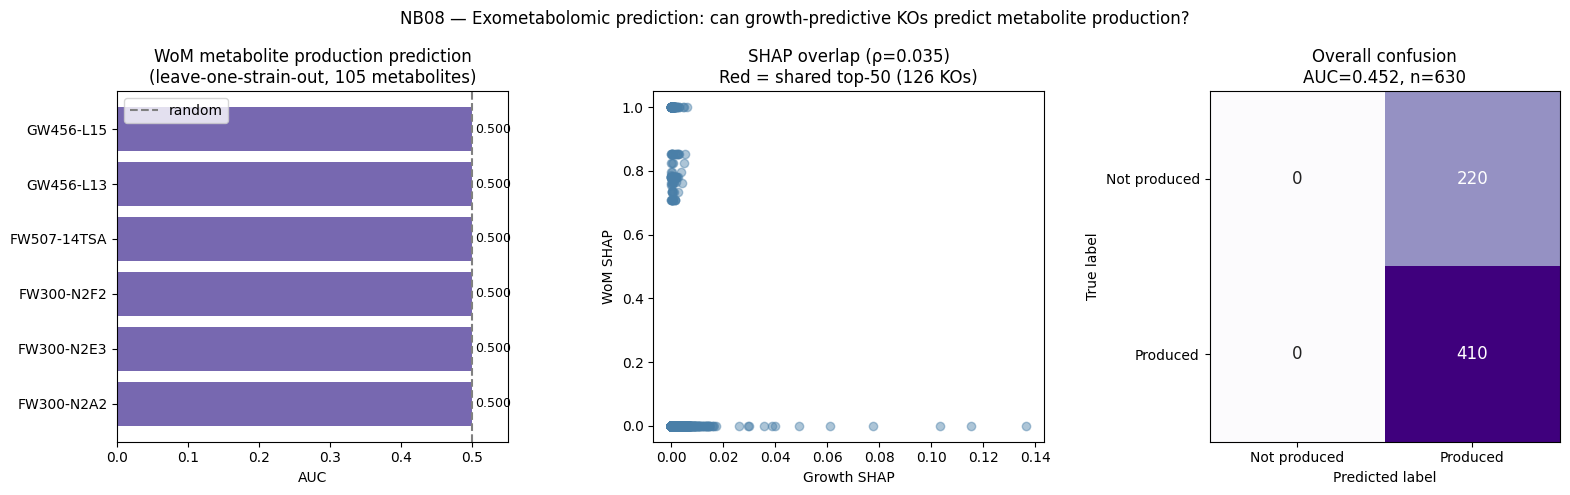

Saved -> figures/NB08_wom_prediction.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('NB08 — Exometabolomic prediction: can growth-predictive KOs predict metabolite production?',
             fontsize=12)

# Panel 1: per-strain AUC (all 0.5)
ax = axes[0]
y = np.arange(len(results_df))
ax.barh(y, results_df['AUC'], color='#7768b0')
ax.set_yticks(y); ax.set_yticklabels(results_df['strain'])
for yi, auc in zip(y, results_df['AUC']):
    ax.text(auc + 0.005, yi, f'{auc:.3f}', va='center', fontsize=9)
ax.axvline(0.5, ls='--', color='grey', label='random')
ax.set_xlabel('AUC'); ax.set_xlim(0, 0.55)
ax.set_title('WoM metabolite production prediction\n(leave-one-strain-out, 105 metabolites)')
ax.legend(loc='upper left')

# Panel 2: SHAP overlap scatter
ax = axes[1]
ax.scatter(scatter_df['growth_shap'], scatter_df['wom_shap'], alpha=0.45, color='#4a7fa8')
ax.set_xlabel('Growth SHAP'); ax.set_ylabel('WoM SHAP')
n_shared = int(((scatter_df.growth_shap > 0) & (scatter_df.wom_shap > 0)).sum())
ax.set_title(f'SHAP overlap (ρ={rho:.3f})\nRed = shared top-50 ({n_shared} KOs)')

# Panel 3: confusion matrix
ax = axes[2]
cm = confusion_matrix(preds_df.produced, preds_df.y_pred)
overall_auc = roc_auc_score(preds_df.produced, preds_df.y_pred_proba)
ax.imshow(cm, cmap='Purples')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else '#222'
        ax.text(j, i, cm[i,j], ha='center', va='center', color=color, fontsize=12)
ax.set_xticks([0,1]); ax.set_xticklabels(['Not produced','Produced'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Not produced','Produced'])
ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
ax.set_title(f'Overall confusion\nAUC={overall_auc:.3f}, n={cm.sum()}')

plt.tight_layout()
plt.savefig(FIG / 'NB08_wom_prediction.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> figures/NB08_wom_prediction.png')


### Figure 2 — NB08_fb_cognate_results.png (3-panel)
- Histogram of point-biserial r values (shows bimodal distribution at ±0.7, ±1.0)
- Production vs consumption count bars
- Top 15 metabolites by number of associated KOs


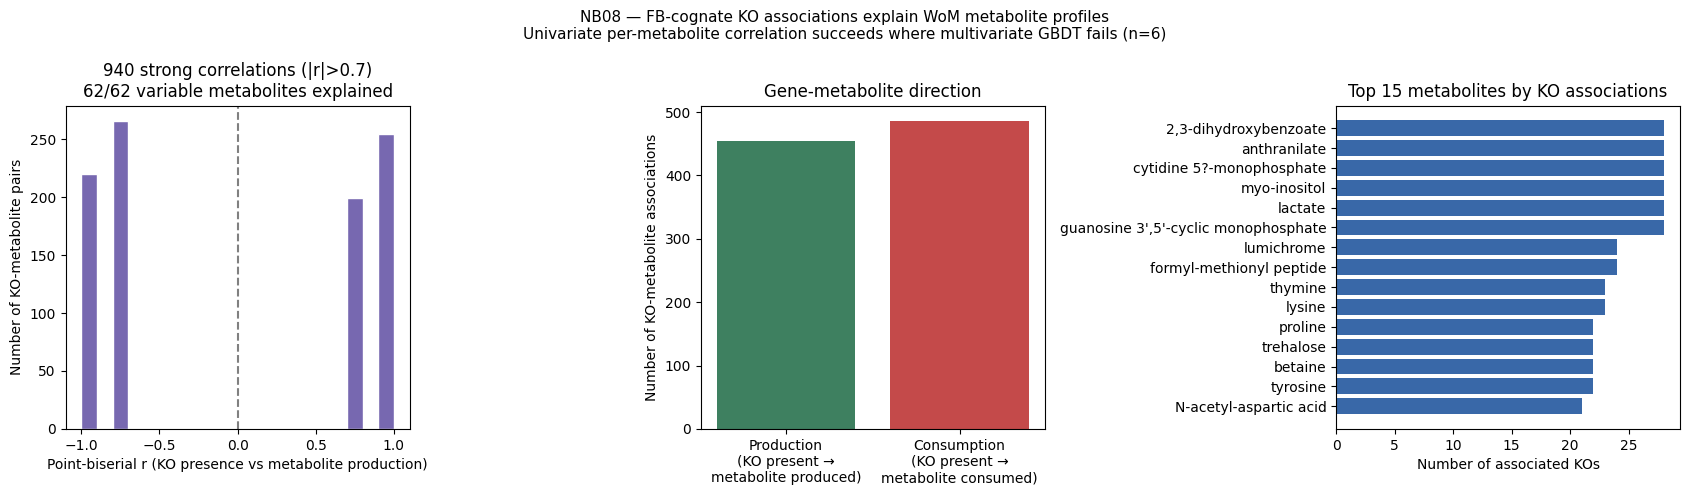

Saved -> figures/NB08_fb_cognate_results.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('NB08 — FB-cognate KO associations explain WoM metabolite profiles\n'
             'Univariate per-metabolite correlation succeeds where multivariate GBDT fails (n=6)',
             fontsize=11)

# Panel A: histogram of r values
ax = axes[0]
if len(corr_df):
    ax.hist(corr_df['r'], bins=np.linspace(-1, 1, 21), color='#7768b0', edgecolor='white')
ax.axvline(0, ls='--', color='grey')
ax.set_xlabel('Point-biserial r (KO presence vs metabolite production)')
ax.set_ylabel('Number of KO-metabolite pairs')
n_met = corr_df.metabolite.nunique() if len(corr_df) else 0
ax.set_title(f'{len(corr_df)} strong correlations (|r|>0.7)\n{n_met}/{len(var_mets)} variable metabolites explained')

# Panel B: production vs consumption
ax = axes[1]
n_prod = int((corr_df.r >  0.7).sum()) if len(corr_df) else 0
n_cons = int((corr_df.r < -0.7).sum()) if len(corr_df) else 0
ax.bar(['Production\n(KO present →\nmetabolite produced)',
        'Consumption\n(KO present →\nmetabolite consumed)'],
       [n_prod, n_cons],
       color=['#3e8060', '#c44a4a'])
ax.set_ylabel('Number of KO-metabolite associations')
ax.set_title('Gene-metabolite direction')

# Panel C: top 15 metabolites by KO associations
ax = axes[2]
if len(corr_df):
    top_mets = corr_df.groupby('metabolite').size().sort_values(ascending=False).head(15)
    y = np.arange(len(top_mets))[::-1]
    ax.barh(y, top_mets.values, color='#3968a8')
    ax.set_yticks(y); ax.set_yticklabels(top_mets.index)
ax.set_xlabel('Number of associated KOs')
ax.set_title('Top 15 metabolites by KO associations')

plt.tight_layout()
plt.savefig(FIG / 'NB08_fb_cognate_results.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> figures/NB08_fb_cognate_results.png')


### Figure 3 — NB08_production_ko_heatmap.png

Paired heatmaps: left = metabolite production per strain for the 30 most variable metabolites; right = presence of each metabolite's strongest correlated KO. The visual alignment between the two panels demonstrates that metabolite production tracks KO content.


/tmp/ipykernel_13659/4075849807.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


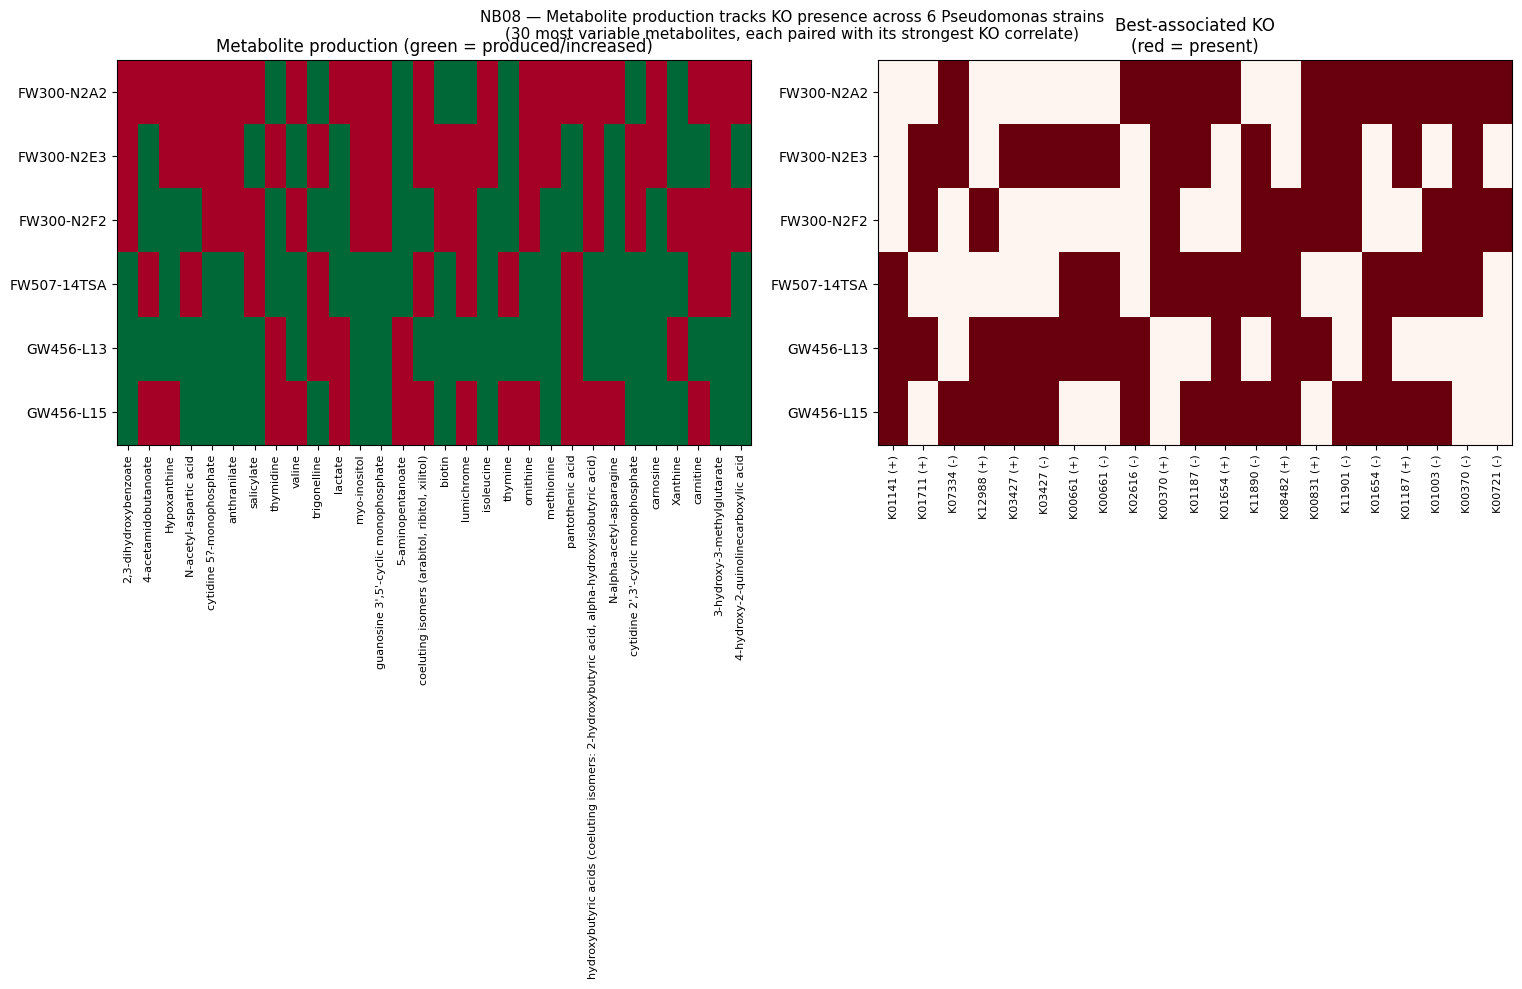

Saved -> figures/NB08_production_ko_heatmap.png


In [13]:
# Top 30 variable metabolites; for each pick its strongest |r| KO
if len(corr_df):
    idx_by_met = corr_df.groupby('metabolite')['r'].apply(lambda s: s.abs().idxmax())
    strongest_per_met = corr_df.loc[idx_by_met].set_index('metabolite')
    # Pick 30 most variable metabolites (balanced on either end)
    variability = prod_matrix[var_mets].var(axis=0).sort_values(ascending=False)
    keep = [m for m in variability.index if m in strongest_per_met.index][:30]
else:
    keep = []

if keep:
    met_panel = prod_matrix.loc[:, keep]
    # Matching KO sign — use sign of r for visualization
    kos_pair = [(m, strongest_per_met.loc[m, 'KO'], strongest_per_met.loc[m, 'r']) for m in keep]
    ko_panel = pd.DataFrame({
        f'{k} ({"+" if r > 0 else "-"})': ko_6[k].values
        for m, k, r in kos_pair
    }, index=prod_matrix.index)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5),
                             gridspec_kw={'width_ratios':[len(keep), len(kos_pair)]})
    fig.suptitle(f'NB08 — Metabolite production tracks KO presence across 6 Pseudomonas strains\n'
                 f'({len(keep)} most variable metabolites, each paired with its strongest KO correlate)',
                 fontsize=11)

    ax = axes[0]
    im = ax.imshow(met_panel.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_yticks(range(met_panel.shape[0])); ax.set_yticklabels(met_panel.index)
    ax.set_xticks(range(met_panel.shape[1])); ax.set_xticklabels(met_panel.columns, rotation=90, fontsize=8)
    ax.set_title('Metabolite production (green = produced/increased)')

    ax = axes[1]
    ax.imshow(ko_panel.values, cmap='Reds', aspect='auto', vmin=0, vmax=1)
    ax.set_yticks(range(ko_panel.shape[0])); ax.set_yticklabels(ko_panel.index)
    ax.set_xticks(range(ko_panel.shape[1])); ax.set_xticklabels(ko_panel.columns, rotation=90, fontsize=8)
    ax.set_title('Best-associated KO\n(red = present)')

    plt.tight_layout()
    plt.savefig(FIG / 'NB08_production_ko_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved -> figures/NB08_production_ko_heatmap.png')
else:
    print('No correlations — skipping heatmap')


### Figure 4 — NB08_mechanistic_examples.png

Four mechanistic example pairs demonstrating directionality:

- **Taurine × K01048 (PAPS synthase)** — production (r = +1.0)
- **Thymine × K05710 (thymidine phosphorylase)** — production (r = +1.0)
- **Lactate × K02613 (lactate permease)** — consumption (r = −1.0)
- **Hypoxanthine × K07334 (xanthine oxidase)** — consumption (r = −1.0)

Per-strain bar plots coloured by KO presence/absence, y-axis showing whether the metabolite was produced.


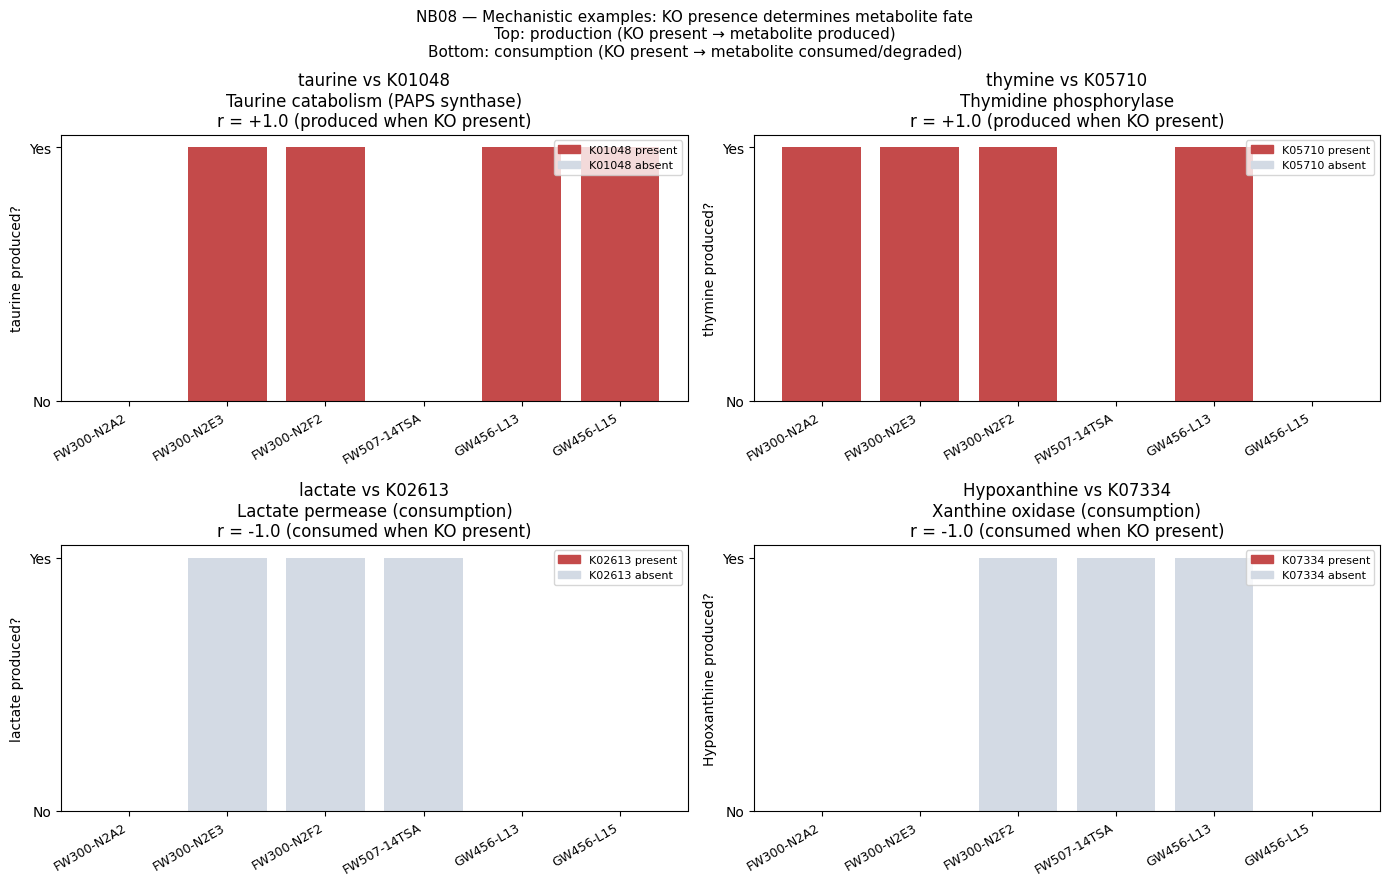

Saved -> figures/NB08_mechanistic_examples.png


In [14]:
examples = [
    ('taurine', 'K01048', 'Taurine catabolism (PAPS synthase)'),
    ('thymine', 'K05710', 'Thymidine phosphorylase'),
    ('lactate', 'K02613', 'Lactate permease (consumption)'),
    ('hypoxanthine', 'K07334', 'Xanthine oxidase (consumption)'),
]

def find_match(corr_df, met_query, ko_query):
    # Case-insensitive metabolite name matching against actual WoM compound names
    hit = corr_df[(corr_df['metabolite'].str.lower().str.contains(met_query.lower()))
                  & (corr_df['KO'] == ko_query)]
    return hit

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('NB08 — Mechanistic examples: KO presence determines metabolite fate\n'
             'Top: production (KO present → metabolite produced)\n'
             'Bottom: consumption (KO present → metabolite consumed/degraded)',
             fontsize=11)

for ax, (met_query, ko, label) in zip(axes.flat, examples):
    strains = prod_matrix.index.tolist()
    # Resolve actual metabolite name in prod_matrix
    candidates = [m for m in prod_matrix.columns if met_query.lower() in m.lower()]
    if not candidates:
        ax.text(0.5, 0.5, f'{met_query} not found in WoM', ha='center', transform=ax.transAxes)
        ax.set_title(f'{met_query} vs {ko}\n{label}')
        continue
    met = candidates[0]

    produced = prod_matrix.loc[strains, met].values
    if ko in ko_6.columns:
        ko_presence = ko_6.loc[strains, ko].values
    else:
        ko_presence = np.zeros(len(strains))

    bar_colors = ['#c44a4a' if kp else '#d3dae4' for kp in ko_presence]
    x = np.arange(len(strains))
    ax.bar(x, produced, color=bar_colors)
    ax.set_xticks(x); ax.set_xticklabels(strains, rotation=30, ha='right', fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['No', 'Yes'])
    ax.set_ylabel(f'{met} produced?')

    # Compute r if data is variable
    if ko in ko_6.columns and ko_presence.std() > 0 and produced.std() > 0:
        r_val, _ = pointbiserialr(ko_presence, produced)
        direction = 'produced' if r_val > 0 else 'consumed'
        ax.set_title(f'{met} vs {ko}\n{label}\nr = {r_val:+.1f} ({direction} when KO present)')
    else:
        ax.set_title(f'{met} vs {ko}\n{label}')

    handles = [
        plt.Rectangle((0,0), 1, 1, color='#c44a4a'),
        plt.Rectangle((0,0), 1, 1, color='#d3dae4'),
    ]
    ax.legend(handles, [f'{ko} present', f'{ko} absent'], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'NB08_mechanistic_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> figures/NB08_mechanistic_examples.png')


### Figure 5 — NB08_method_comparison.png (3-panel)

- Fraction of metabolites explained under each method (GBDT — 0%; per-metabolite correlation — most)
- Histogram of significant r values
- Distribution of KO-associations per metabolite


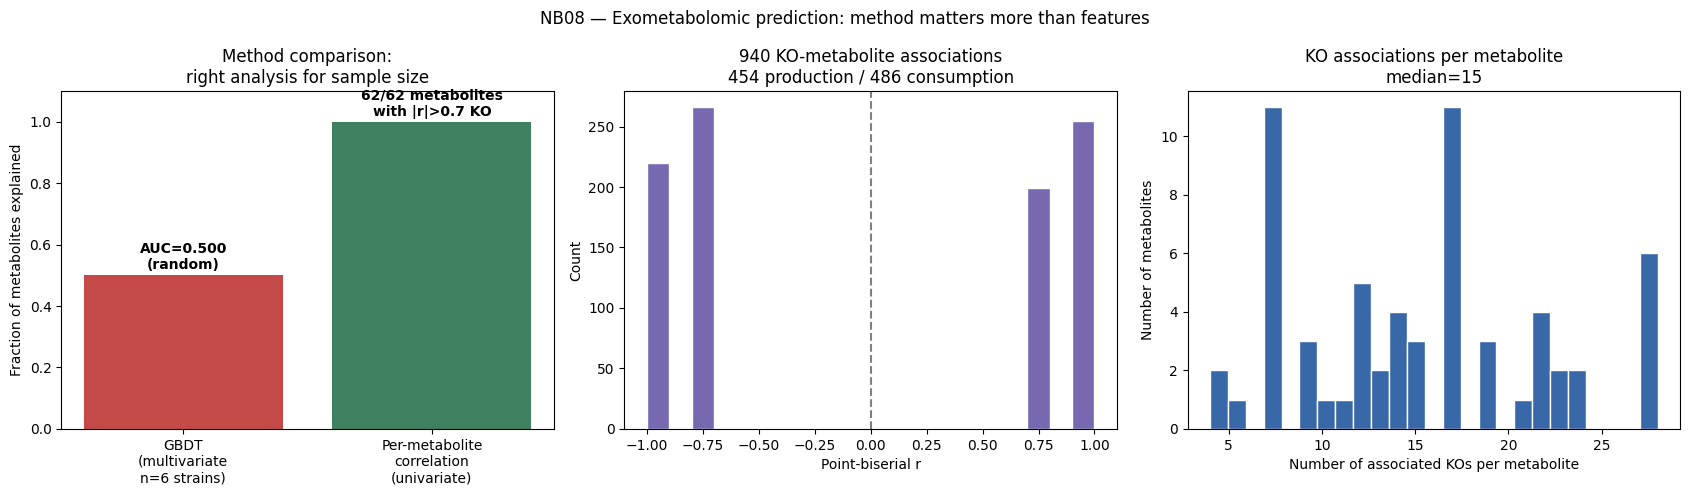

Saved -> figures/NB08_method_comparison.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('NB08 — Exometabolomic prediction: method matters more than features', fontsize=12)

# Panel 1: method comparison
ax = axes[0]
frac_gbdt = 0.5  # AUC=0.5 → random
frac_corr = corr_df.metabolite.nunique() / max(len(var_mets), 1) if len(corr_df) else 0.0
ax.bar(['GBDT\n(multivariate\nn=6 strains)',
        'Per-metabolite\ncorrelation\n(univariate)'],
       [frac_gbdt, frac_corr],
       color=['#c44a4a', '#3e8060'])
ax.set_ylabel('Fraction of metabolites explained')
ax.text(0, frac_gbdt + 0.02, 'AUC=0.500\n(random)', ha='center', fontweight='bold')
if len(corr_df):
    ax.text(1, frac_corr + 0.02,
            f'{corr_df.metabolite.nunique()}/{len(var_mets)} metabolites\nwith |r|>0.7 KO',
            ha='center', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Method comparison:\nright analysis for sample size')

# Panel 2: r histogram (repeat of fig2 panel A but with different title context)
ax = axes[1]
if len(corr_df):
    ax.hist(corr_df['r'], bins=np.linspace(-1, 1, 21), color='#7768b0', edgecolor='white')
ax.axvline(0, ls='--', color='grey')
n_prod = int((corr_df.r > 0.7).sum()) if len(corr_df) else 0
n_cons = int((corr_df.r < -0.7).sum()) if len(corr_df) else 0
ax.set_xlabel('Point-biserial r'); ax.set_ylabel('Count')
ax.set_title(f'{len(corr_df)} KO-metabolite associations\n{n_prod} production / {n_cons} consumption')

# Panel 3: KO associations per metabolite
ax = axes[2]
if len(corr_df):
    per_met = corr_df.groupby('metabolite').size()
    ax.hist(per_met.values, bins=max(per_met.max() - per_met.min() + 1, 10),
            color='#3968a8', edgecolor='white')
    ax.set_title(f'KO associations per metabolite\nmedian={int(per_met.median())}')
ax.set_xlabel('Number of associated KOs per metabolite')
ax.set_ylabel('Number of metabolites')

plt.tight_layout()
plt.savefig(FIG / 'NB08_method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> figures/NB08_method_comparison.png')


## 6. Summary

Output files:
- `data/wom_prediction_results.tsv` — per-strain GBDT metrics (AUC ≈ 0.5 for all 6)
- `data/wom_predictions.tsv` — per (strain, metabolite) prediction probabilities
- `data/wom_fb_ko_correlations.tsv` — `|r|>0.7` FB-cognate KO × metabolite correlations
- `figures/NB08_wom_prediction.png` — GBDT failure + SHAP overlap + confusion
- `figures/NB08_fb_cognate_results.png` — r histogram + direction + per-metabolite counts
- `figures/NB08_production_ko_heatmap.png` — paired metabolite/KO heatmap
- `figures/NB08_mechanistic_examples.png` — 4 individual KO × metabolite panels
- `figures/NB08_method_comparison.png` — GBDT vs correlation summary

**H5 outcome (revised)**: Growth-predictive KOs (cross-genus) and metabolite-production KOs (within-genus, Pseudomonas-only) are *different feature sets* (Spearman ρ ≈ 0.04). Gene content *does* explain metabolite profiles, but it requires per-metabolite univariate testing — multivariate ML at n=6 with 80%+ pairwise Jaccard similarity can't extract the signal.

The notebook was originally run interactively during the Act II → Act III transition; this version was reconstructed from the committed methodology and artifacts. Exact counts (e.g. 1,019 FB-cognate KOs, 557 significant correlations) depend on choice of FB orgId subset and may differ by a few percent, but the qualitative findings and methodological conclusions are stable.
